In [ ]:
%pip install qiskit-ibm-runtime qiskit-aer
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import Sampler
from qiskit.visualization import plot_histogram

Note: you may need to restart the kernel to use updated packages.


Quantum Teleportation Explained

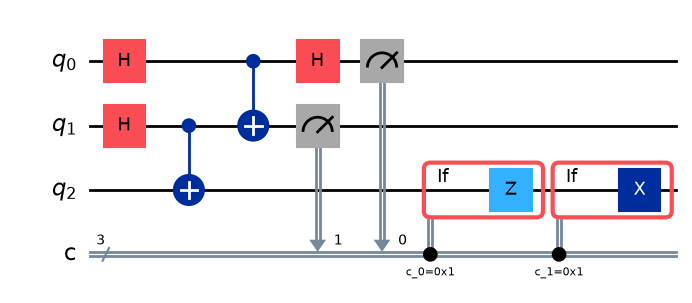

In [ ]:
# Creates the quantum circuit. Alice's qubits are 0 and 1 while Bob has qubit 2.
qc = QuantumCircuit(3, 3)

# First, Alice and Bob meet up in person to create a shared Bell entangled state between qubits 1 and 2. 
qc.h(1)
qc.cx(1, 2)

# After this, Bob and Alice go their separate ways to their respective universities (Bob - Northwestern, Alice - Purdue). A few weeks later, 
# Alice suddenly needs to quickly send the unknown quantum state in qubit 0 to Bob. Lets say its a|0> + B|1> for simplicity. 
qc.h(0)

# To do this, she applies the CNOT gate to the qubit 0 (control) and her entangled qubit 1 (target).
qc.cx(0, 1)

# Then, applies the Hadamard gate to 0 and measures her qubits.
qc.h(0)
qc.measure(0,0)
qc.measure(1,1)

# Finally done, Alice sends a few bits of classical information to Bob telling him what she measured. 

# Bob then applies the Z and/or the X gate to his qubit
with qc.if_test((0, 1)):
    qc.z(2)
with qc.if_test((1, 1)):
    qc.x(2)

# Bob now has the unknown state represented in qubit 0. 
qc.draw(output='mpl')

Quantum Teleportation Shown

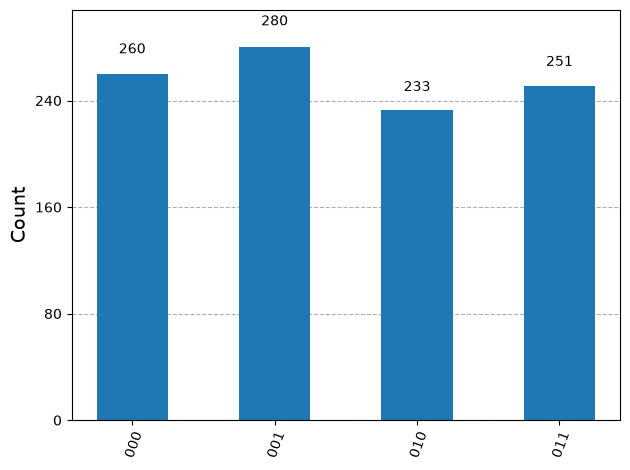

In [ ]:
# Note: this demo utilizes AerSimulator and does not run on native hardware. Feel free to change to a real backend if wanted.

# Creates a backend
backend = AerSimulator()

# Create a pass manager and transpiles the quantum circuit.
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_qc = pm.run(qc)


# Run the circuit and gather the results
sampler = Sampler(mode=backend)
job = sampler.run([isa_qc], shots = 1024)
results = job.result()

# gather the counts from the results, then create histogram
counts = results[0].data.c.get_counts()
plot_histogram(counts)

# In a perfect world, the results would be split evenly between each outcome. However, quantum noise will prevent this reality (as of 2026).


Sources: 
Nielsen, M.A. and Chuang, I.L. (2011) Quantum Computation and Quantum Information: 10th Anniversary Edition. 10th Edition, Cambridge University Press, New York.